### Diabetes data set

#### Import libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Data Gathering

In [3]:
df = pd.read_csv('autos_diabetes.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'autos_diabetes.csv'

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
X = df.drop(['Outcome'], axis = 1)
y = df['Outcome']

In [5]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

#### Split Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                   test_size=0.20, random_state=42)

In [7]:
y_train.value_counts()

Outcome
0    401
1    213
Name: count, dtype: int64

In [8]:
df['Outcome'].unique()

array([1, 0])

<Axes: xlabel='Outcome', ylabel='count'>

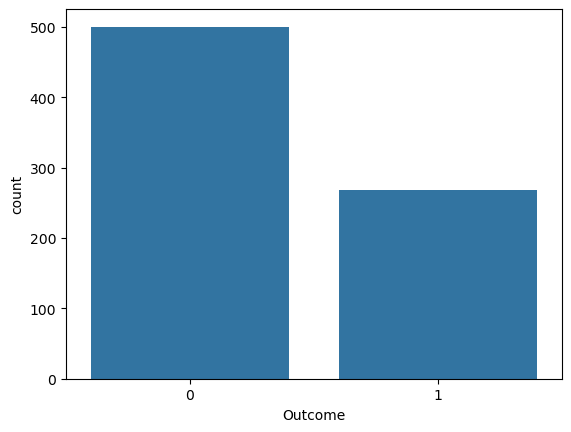

In [9]:
sns.countplot(x = df['Outcome'])

#### Build Decision Tree Model

In [10]:
dt_model = DecisionTreeClassifier(criterion='gini')
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Training data Accuarcy

In [11]:
y_pred_train = dt_model.predict(X_train)
y_pred_train[10:15]

train_accuarcy = accuracy_score(y_train, y_pred_train)
print('Training data accuracy is : \n', train_accuarcy)

print()

clf_report = classification_report(y_train, y_pred_train)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_train, y_pred_train)
print('Confusion matrix is :\n', cnf_matrix)

Training data accuracy is : 
 1.0

Classification report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       401
           1       1.00      1.00      1.00       213

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614


Confusion matrix is :
 [[401   0]
 [  0 213]]


### Testing data Accuarcy

In [12]:
y_pred_test = dt_model.predict(X_test)
y_pred_test[10:15]

test_accuarcy = accuracy_score(y_test, y_pred_test)
print('Testing data accuracy is : \n', test_accuarcy)

print()

clf_report = classification_report(y_test, y_pred_test)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_test, y_pred_test)
print('Confusion matrix is :\n', cnf_matrix)

Testing data accuracy is : 
 0.7532467532467533

Classification report :
               precision    recall  f1-score   support

           0       0.84      0.76      0.80        99
           1       0.63      0.75      0.68        55

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154


Confusion matrix is :
 [[75 24]
 [14 41]]


In [13]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [14]:
y_train.value_counts()

Outcome
0    401
1    213
Name: count, dtype: int64

In [15]:
y_test.value_counts()

Outcome
0    99
1    55
Name: count, dtype: int64

### Plot Decision Tree

In [16]:
# plt.figure(figsize=(200,100))
# tree = plot_tree(decision_tree = dt_model, feature_names=df.columns, 
#                  class_names=['0','1'], filled = True)
# plt.savefig('DT_Diabetes.png')

### Hyperparameter tuning

#### 1. GrisSearchCV

In [17]:
hyperparameters = {'criterion' : ['gini', 'entropy'],
                    'max_depth' : np.arange(2,10),
                    'min_samples_split' : np.arange(2,15),
                     'min_samples_leaf' : np.arange(2,16)}
dt_model = DecisionTreeClassifier()
dt_model
gscv_dt_model = GridSearchCV(dt_model, hyperparameters, cv=5)
gscv_dt_model.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': array([2, 3, ..., 6, 7, 8, 9]), 'min_samples_leaf': array([ 2, 3..., 13, 14, 15]), 'min_samples_split': array([ 2, 3..., 12, 13, 14])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [18]:
gscv_dt_model.best_params_

{'criterion': 'gini',
 'max_depth': np.int64(7),
 'min_samples_leaf': np.int64(15),
 'min_samples_split': np.int64(2)}

In [19]:
best_dt_model = DecisionTreeClassifier(max_depth=7, min_samples_leaf=15
                                      , min_samples_split=2)
best_dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Training data accuracy GridSearchCV

In [20]:
y_pred_train = best_dt_model.predict(X_train)
y_pred_train[10:15]

train_accuarcy = accuracy_score(y_train, y_pred_train)
print('Training data accuracy is : \n', train_accuarcy)

print()

clf_report = classification_report(y_train, y_pred_train)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_train, y_pred_train)
print('Confusion matrix is :\n', cnf_matrix)

Training data accuracy is : 
 0.8371335504885994

Classification report :
               precision    recall  f1-score   support

           0       0.90      0.85      0.87       401
           1       0.74      0.81      0.78       213

    accuracy                           0.84       614
   macro avg       0.82      0.83      0.82       614
weighted avg       0.84      0.84      0.84       614


Confusion matrix is :
 [[341  60]
 [ 40 173]]


#### Testing data accuracy GridSearchCV

In [21]:
y_pred_test = best_dt_model.predict(X_test)
y_pred_test[10:15]

test_accuarcy = accuracy_score(y_test, y_pred_test)
print('Testing data accuracy is : \n', test_accuarcy)

print()

clf_report = classification_report(y_test, y_pred_test)
print('Classification report :\n', clf_report)

print()

cnf_matrix = confusion_matrix(y_test, y_pred_test)
print('Confusion matrix is :\n', cnf_matrix)

Testing data accuracy is : 
 0.7272727272727273

Classification report :
               precision    recall  f1-score   support

           0       0.83      0.73      0.77        99
           1       0.60      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154


Confusion matrix is :
 [[72 27]
 [15 40]]


In [23]:
# ============================================================
# SAVE TRAINED MODEL AS PICKLE FILE
# ============================================================

import pickle

# Save the trained Decision Tree model
with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(best_dt_model, file)

print(" Model saved successfully as diabetes_model.pkl")


# ============================================================
# SAVE FEATURE NAMES
# ============================================================

features = X.columns.tolist()

with open("diabetes_features.pkl", "wb") as file:
    pickle.dump(features, file)

print(" Features saved successfully as diabetes_features.pkl")

print("\nFeatures used by model:")
print(features)

 Model saved successfully as diabetes_model.pkl
 Features saved successfully as diabetes_features.pkl

Features used by model:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
